# Predict regulatory regions around LMNA (AlphaGenome)

This notebook runs AlphaGenome interval predictions for left-ventricle heart tissue around *LMNA*, then isolates high-signal candidate regulatory regions from chromatin / transcription modalities. Predicted intervals can be exported as BED and overlaid on track plots (and compared to ENCODE cCREs).

**Run with the AG kernel.**


# Setup

Load libraries, shared paths/constants, the AlphaGenome model, and GENCODE transcript extractors used throughout.


## Imports

**Make sure to run using AG kernel**


In [2]:
from alphagenome_research.model import dna_model
from alphagenome import colab_utils
from alphagenome.data import gene_annotation
from alphagenome.data import genome
from alphagenome.data import transcript
from alphagenome.data import ontology
from alphagenome.interpretation import ism
from alphagenome.models import dna_client
from alphagenome.models import variant_scorers
from alphagenome.visualization import plot_components
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.93'

import matplotlib.pyplot as plt
import pandas as pd
from pysam import VariantFile
from io import StringIO
from tqdm import tqdm
import os
import re
# from dotenv import load_dotenv
from alphagenome_research.model import dna_model

pd.set_option('display.max_columns', None)

## Common use variables

LMNA locus coordinates, data paths, ontology terms (heart / LV), requested output modalities, and plot color maps.


In [64]:
LMNA_START = 156_114_711
LMNA_END = 156_140_081
gene_symbol = "LMNA"
LMNA_INTERVAL = genome.Interval('chr1', 156_114_711, 156_140_081)


BASE_PATH = '/users/PAS2905/coraalbers/'
AG_DATA_PATH = '/users/PAS2905/coraalbers/ag/ag_data/'

HG38_FASTA_PATH = '/users/PAS2905/coraalbers/ag/hg38.fa'
HG38_GTF_PATH = '/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.annotation.gtf.gz.feather'
HG38_SPLICE_START_PATH = '/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.splice_sites_starts.feather'
HG38_SPLICE_END_PATH = '/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.splice_sites_ends.feather'

HEART_UB = 'UBERON:0000948' # heart
LV_UB = 'UBERON:0002084' # LV

# HG38_GTF_PATH = pd.read_feather( 'https://storage.googleapis.com/alphagenome/reference/gencode/' 'hg38/gencode.v46.annotation.gtf.gz.feather' )

output_modalities = ['atac',	
    'cage',	
    'chip_histone',	
    'chip_tf',	
    'contact_maps',	
    'dnase',	
    'procap',	
    'rna_seq',	
    'splice_junctions',	
    'splice_site_usage',	
    'splice_sites']

requested_outputs = {dna_client.OutputType.ATAC,
        dna_client.OutputType.CAGE,
        dna_client.OutputType.DNASE,
        dna_client.OutputType.PROCAP,
        dna_client.OutputType.RNA_SEQ,
        dna_client.OutputType.SPLICE_SITES,
        dna_client.OutputType.SPLICE_SITE_USAGE,
        dna_client.OutputType.SPLICE_JUNCTIONS,
        dna_client.OutputType.CONTACT_MAPS,
        dna_client.OutputType.CHIP_HISTONE,
        dna_client.OutputType.CHIP_TF}


MODALITY_COLORS = {
    "dnase": "#e377c2",          # pink
    "atac": "#17becf",           # cyan
    "chip_histone": "#d62728",   # red
    "chip_tf": "#9467bd",        # purple
    "rna_seq": "#2ca02c",        # green
    "cage": "#8c564b",           # brown
    "splice": "#ff7f0e",         # orange
    "contact_maps": "#1f77b4",   # blue
}

HISTONE_MARKS = ["H3K4me3", "H3K4me1", "H3K9ac", "H3K27ac", "H3K36me3", "H3K9me3", "H3K27me3"]

HISTONE_COLORS = {
    "H3K4me3": "#e41a1c",   # red — active promoter
    "H3K4me1": "#ff7f00",   # orange — enhancer
    "H3K9ac": "#984ea3",    # purple — active chromatin
    "H3K27ac": "#4daf4a",   # green — active enhancer/promoter
    "H3K36me3": "#377eb8",  # blue — gene body / elongation
    "H3K9me3": "#a65628",   # brown — heterochromatin / repression
    "H3K27me3": "#025669",

}

## Load AlphaGenome model

Create the Hugging Face AlphaGenome model with local hg38 FASTA / GENCODE feather references.


In [4]:
# load_dotenv()
# api_key = os.getenv("AG_API_KEY")

# dna_model = dna_client.create(api_key)

model = dna_model.create_from_huggingface( 
    'all_folds', 
    organism_settings={ 
        dna_model.Organism.HOMO_SAPIENS: dna_model.OrganismSettings( 
            fasta_path=HG38_FASTA_PATH, 
            gtf_feather_path=HG38_GTF_PATH, 
            splice_site_starts_feather_path=HG38_SPLICE_START_PATH, 
            splice_site_ends_feather_path=HG38_SPLICE_END_PATH, 
        ), dna_model.Organism.MUS_MUSCULUS: dna_model.OrganismSettings() } )

Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 1313.08it/s]


## Gene and transcript annotations

Load GENCODE, filter to high-support protein-coding transcripts, and build extractors for all transcripts and longest-per-gene.


In [5]:
# Load gene annotations (from GENCODE).
gtf = pd.read_feather('/users/PAS2905/coraalbers/ag/ag_data/gencode.v46.annotation.gtf.gz.feather')

# Filter to protein-coding genes and highly supported transcripts.
gtf_transcript = gene_annotation.filter_transcript_support_level(
    gene_annotation.filter_protein_coding(gtf), ['1']
)

# Extractor for identifying transcripts in a region.
transcript_extractor = transcript.TranscriptExtractor(gtf_transcript)

# Also define an extractor that fetches only the longest transcript per gene.
gtf_longest_transcript = gene_annotation.filter_to_longest_transcript(
    gtf_transcript
)
longest_transcript_extractor = transcript.TranscriptExtractor(
    gtf_longest_transcript
)



# Predict interval

Define 1 Mb PRE / POST / central windows around LMNA, choose the active interval (currently PRE), set LV ontology terms, and run `model.predict_interval`. Also extract longest transcripts in the interval for plotting.


In [82]:
window_bp = 1_000_000

# gene_interval = gene_annotation.get_gene_interval(gtf, gene_symbol=gene_symbol)
# region = gene_interval.pad(window_bp, window_bp)

# Define interval to make predictions for (used throughout this tutorial).
# Note that the interval width must be one of the supported sequence lengths.


CENTRAL_INTERVAL = LMNA_INTERVAL.resize(
    dna_client.SEQUENCE_LENGTH_1MB)
POST_INTERVAL = genome.Interval('chr1', LMNA_END , LMNA_END + 1000000).resize(
    dna_client.SEQUENCE_LENGTH_1MB)
PRE_INTERVAL = genome.Interval('chr1', LMNA_START - 1000000, LMNA_START).resize(
    dna_client.SEQUENCE_LENGTH_1MB)


interval = POST_INTERVAL
lmna_context = 'post'

print(interval)

# Define the tissues/cell-types to predict expression for.
ontology_terms = [
    # HEART_UB, # heart
    LV_UB
]

# Make predictions.
output = model.predict_interval(
    interval=interval,
    requested_outputs=requested_outputs,
    ontology_terms=ontology_terms,
)

# Extract the longest transcripts per gene for this interval.
longest_transcripts = longest_transcript_extractor.extract(interval)

print("prediction finished")

chr1:156115793-157164369:.
prediction finished


# Load ENCODE cCREs

Import candidate cis-regulatory elements from the ENCODE CSV and filter to those overlapping the prediction `interval`. Colors map cCRE classes for later overlays.


In [19]:
CCRE_CSV = AG_DATA_PATH + "lmna_cCREs_chr1_156041767_156213024.csv"

def load_ccre_intervals(csv_path, plot_interval=None):
    ccres = pd.read_csv(csv_path, skiprows=1, names=[
        "chrom", "chromStart", "chromEnd", "name", "score", "strand",
        "thickStart", "thickEnd", "reserved", "cCRE_class",
        "DNase_maxZ", "H3K4me3_maxZ", "H3K27ac_maxZ", "CTCF_maxZ",
    ])
    intervals = [
        genome.Interval(
            chromosome=row.chrom,
            start=int(row.chromStart),
            end=int(row.chromEnd),
            name=row.name,
            info={"cCRE_class": row.cCRE_class},
        )
        for _, row in ccres.iterrows()
    ]
    if plot_interval is not None:
        intervals = [iv for iv in intervals if iv.overlaps(plot_interval)]
    return intervals, ccres


ccre_intervals, ccres_df = load_ccre_intervals(CCRE_CSV, interval)

CCRE_COLORS = {
    "Promoter": "#FF0000",              # red          RGB(255, 0, 0)
    "Proximal enhancer": "#FFA700",     # orange       RGB(255, 167, 0)
    "Distal enhancer": "#FFCD00",       # yellow/gold  RGB(255, 205, 0)
    "CA": "#06DA93",                    # teal/green   RGB(6, 218, 147)
    "CA-CTCF": "#00B0F0",               # cyan/blue    RGB(0, 176, 240)
    "CA-H3K4me3": "#FFAAAA",            # light pink   RGB(255, 170, 170)
    "TF": "#D876EC",                    # purple       RGB(216, 118, 236)
}

ccre_colors = [
    CCRE_COLORS.get(iv.info.get("cCRE_class"), "gray")
    for iv in ccre_intervals
]

# Helper functions for regulatory peaks

Shared utilities to filter tracks by tissue/name, collapse multi-track profiles, z-score signal, threshold bins, and merge nearby intervals.


## Track selection and signal utilities

`select_tracks`, `collapse_tracks`, `zscore`, combined regulatory profile helpers, thresholding, bin→interval conversion, and peak annotation.


In [8]:
def select_tracks(tdata, *, tissue_curie=None, name_contains=None, strand=None):
    """Return a TrackData subset matching metadata filters."""
    if tdata is None:
        return None
    md = tdata.metadata
    mask = pd.Series(True, index=md.index)
    if tissue_curie is not None and "ontology_curie" in md.columns:
        mask &= md["ontology_curie"] == tissue_curie
    if name_contains is not None:
        mask &= md["name"].str.contains(name_contains, case=False, na=False)
    if strand is not None:
        mask &= md["strand"] == strand
    if not mask.any():
        return None
    return tdata.filter_tracks(mask.to_numpy())

# collapse tracks to 1D profile
def collapse_tracks(tdata, how="max"):
    """Collapse (bins, tracks) -> (bins,) signal."""
    if tdata is None or tdata.num_tracks == 0:
        return None
    vals = tdata.values
    if how == "max":
        return vals.max(axis=1)
    if how == "mean":
        return vals.mean(axis=1)
    raise ValueError(how)


# calculate z-score 
def zscore(x):
    mu, sd = x.mean(), x.std()
    return (x - mu) / sd if sd > 0 else x * 0


# combine tracks per modality based on max z score out of all of the tracks
def combined_regulatory_profile(output, tissue_curie="UBERON:0000948"):
    profiles = []

    dnase = select_tracks(output.dnase, tissue_curie=tissue_curie)
    if dnase is not None:
        profiles.append(zscore(collapse_tracks(dnase, "max")))
        print("appending dnase track")

    atac = select_tracks(output.atac, tissue_curie=tissue_curie)
    if atac is not None:
        profiles.append(zscore(collapse_tracks(atac, "max")))
        print("appending atac track")

    h3k4me3 = select_tracks(
        output.chip_histone,
        tissue_curie=tissue_curie,
        name_contains="H3K4me3",)
    h3k4me1 = select_tracks(
        output.chip_histone,
        tissue_curie=tissue_curie,
        name_contains="H3K4me1",)
    h3k9ac = select_tracks(
        output.chip_histone,
        tissue_curie=tissue_curie,
        name_contains="H3K9ac",)
    h3k27ac = select_tracks(
        output.chip_histone,
        tissue_curie=tissue_curie,
        name_contains="H3K27ac",)
    h3k36me3 = select_tracks(
        output.chip_histone,
        tissue_curie=tissue_curie,
        name_contains="H3K36me3",)
    
    
    if h3k4me3 is not None:
        profiles.append(zscore(collapse_tracks(h3k4me3, "max")))
        print("appending h3k4me3 track")
    if h3k4me1 is not None:
        profiles.append(zscore(collapse_tracks(h3k4me1, "max")))
        print("appending h3k4me1 track")
    if h3k9ac is not None:
        profiles.append(zscore(collapse_tracks(h3k9ac, "max")))
        print("appending h3k9ac track")
    if h3k27ac is not None:
        profiles.append(zscore(collapse_tracks(h3k27ac, "max")))
        print("appending h3k27ac track")
    if h3k36me3 is not None:
        profiles.append(zscore(collapse_tracks(h3k36me3, "max")))
        print("appending h3k36me3 track")
    
    if not profiles:
        raise ValueError("No tracks matched filters")

    stacked = np.stack(profiles, axis=1)
    return stacked.max(axis=1)   # or .mean(axis=1) for softer consensus


# define threshold of "high scoring" as default 95th percentile
def threshold_bins(signal, method="percentile", value=95):
    if method == "percentile":
        cutoff = np.percentile(signal, value)
    elif method == "std":
        cutoff = signal.mean() + value * signal.std()
    else:
        cutoff = value
    return signal >= cutoff, cutoff


# convert continuous high scoring bins into one interval
def bins_to_intervals(signal, mask, interval, resolution):
    """Turn a boolean mask over bins into merged genomic intervals."""
    regions = []
    in_region = False
    start_bin = None

    for i, is_high in enumerate(mask):
        if is_high and not in_region:
            start_bin = i
            in_region = True
        elif not is_high and in_region:
            regions.append((start_bin, i))
            in_region = False
    if in_region:
        regions.append((start_bin, len(mask)))

    intervals = []
    for b0, b1 in regions:
        start = interval.start + b0 * resolution
        end = interval.start + b1 * resolution
        intervals.append(genome.Interval(interval.chromosome, start, end))
    return intervals


# merge intervals that are within gap# of bp 
def merge_nearby(intervals, gap=200):
    if not intervals:
        return []
    intervals = sorted(intervals, key=lambda x: x.start)
    merged = [intervals[0]]
    for iv in intervals[1:]:
        prev = merged[-1]
        if iv.start - prev.end <= gap:
            merged[-1] = genome.Interval(
                prev.chromosome, prev.start, max(prev.end, iv.end)
            )
        else:
            merged.append(iv)
    return merged


# add peak scores
def annotate_peak_scores(intervals, signal, interval, resolution):
    for iv in intervals:
        b0 = (iv.start - interval.start) // resolution
        b1 = (iv.end - interval.start) // resolution
        iv.info["max_signal"] = float(signal[b0:b1].max())
        iv.info["mean_signal"] = float(signal[b0:b1].mean())
    return sorted(intervals, key=lambda x: x.info["max_signal"], reverse=True)





## Isolate high regions (multi-modality max z-score)

`isolate_high_regulatory_regions` collapses selected modalities (optionally a histone mark), takes the max z-score across profiles, thresholds (default 95th percentile), merges nearby peaks, and annotates scores.


In [9]:
def isolate_high_regulatory_regions(
    output,
    *,
    tissue_curie=LV_UB,
    modalities=("dnase", "cage", "chip_histone"),
    histone_mark=None,
    collapse="max",
    resolution_bp=128,
    threshold_method="percentile",
    threshold_value=95,
    min_width_bp=500,
    merge_gap_bp=200,):

    
    profiles = []
    anchor_interval = None
    anchor_resolution = resolution_bp

    def process(tdata):
        nonlocal anchor_interval
        if tdata is None or tdata.num_tracks == 0:
            return
        tdata = tdata.change_resolution(resolution_bp)
        collapsed = collapse_tracks(tdata, collapse)
        if collapsed is None:
            return
        anchor_interval = tdata.interval
        profiles.append(zscore(collapsed))

    modality_map = {
        "dnase": select_tracks(output.dnase, tissue_curie=tissue_curie),
        "atac": select_tracks(output.atac, tissue_curie=tissue_curie),
        "chip_histone": select_tracks(
            output.chip_histone,
            tissue_curie=tissue_curie,
            name_contains=histone_mark,
        ),
        "chip_tf": select_tracks(output.chip_tf, tissue_curie=tissue_curie),
        "cage": select_tracks(output.cage, tissue_curie=tissue_curie, strand='+'), # only pos strand b/c LMNA is on + strand only
    }

    for m in modalities:
        # print(m)
        process(modality_map[m])

    if not profiles:
        raise ValueError(
            f"No tracks matched filters for modalities={list(modalities)}, "
            f"tissue_curie={tissue_curie}, histone_mark={histone_mark}"
        )

    # gets max score across all profiles
    signal = np.stack(profiles, axis=1).max(axis=1)
    # print(signal[:10])
    mask, cutoff = threshold_bins(signal, threshold_method, threshold_value)

    intervals = bins_to_intervals(signal, mask, anchor_interval, anchor_resolution)
    
    intervals = [iv for iv in intervals if iv.width >= min_width_bp]

    # merge intervals that are within merge_gap_bp range of each other
    intervals = merge_nearby(intervals, merge_gap_bp)

    # calculate peak scores for intervals
    intervals = annotate_peak_scores(intervals, signal, anchor_interval, anchor_resolution)

    return {
        "intervals": intervals,
        "signal": signal,
        "cutoff": cutoff,
        "resolution": anchor_resolution,
        "anchor_interval": anchor_interval,
    }


## Isolate high regions (single modality)

Same peak-calling pipeline restricted to one modality at a time via `isolate_high_regulatory_regions_singlemod`.


In [10]:
def isolate_high_regulatory_regions_singlemod(
    output,
    *,
    tissue_curie="UBERON:0000948",
    modalities=["dnase"],
    histone_mark="H3K4",
    collapse="max",
    resolution_bp=1,
    threshold_method="percentile",
    threshold_value=95,
    min_width_bp=500,
    merge_gap_bp=200,):

    
    profiles = []
    anchor_interval = None
    anchor_resolution = resolution_bp

    def process(tdata):
        nonlocal anchor_interval
        if tdata is None or tdata.num_tracks == 0:
            return
        tdata = tdata.change_resolution(resolution_bp)
        collapsed = collapse_tracks(tdata, collapse)
        if collapsed is None:
            return
        anchor_interval = tdata.interval
        profiles.append(zscore(collapsed))

    modality_map = {
        "dnase": select_tracks(output.dnase, tissue_curie=tissue_curie),
        "atac": select_tracks(output.atac, tissue_curie=tissue_curie),
        "chip_histone": select_tracks(
            output.chip_histone,
            tissue_curie=tissue_curie,
            name_contains=histone_mark,
        ),
        "chip_tf": select_tracks(output.chip_tf, tissue_curie=tissue_curie),
        "cage": select_tracks(output.cage, tissue_curie=tissue_curie, strand='+'),
    }

    for m in range(len(modalities)):
        modality = modalities[m]
        print(modality)
        process(modality_map[modality])

    print(profiles)

    if not profiles:
        raise ValueError(
            f"No tracks matched filters for modalities={list(modalities)}, "
            f"tissue_curie={tissue_curie}, histone_mark={histone_mark}"
        )

    # gets max score across all profiles
    signal = np.stack(profiles, axis=1).max(axis=1)
    print(signal[:10])
    mask, cutoff = threshold_bins(signal, threshold_method, threshold_value)

    intervals = bins_to_intervals(signal, mask, anchor_interval, anchor_resolution)
    
    intervals = [iv for iv in intervals if iv.width >= min_width_bp]

    # merge intervals that are within merge_gap_bp range of each other
    intervals = merge_nearby(intervals, merge_gap_bp)

    # calculate peak scores for intervals
    intervals = annotate_peak_scores(intervals, signal, anchor_interval, anchor_resolution)

    return {
        "intervals": intervals,
        "signal": signal,
        "cutoff": cutoff,
        "resolution": anchor_resolution,
        "anchor_interval": anchor_interval,
    }

# Inspect prediction outputs

Check which tracks are available for LV after tissue filters, peek ontology-filtered metadata, and list plus-strand gene names in the interval.


## Track counts and tissue filters

Print metadata summaries for DNase, ATAC, ChIP, and CAGE, and verify `select_tracks` filters.


In [25]:
tissue_curie = LV_UB

for name, tdata in [
    ("dnase", output.dnase),
    ("atac", output.atac),
    ("chip_histone", output.chip_histone),
    ("chip_tf", output.chip_tf),
    ("cage", output.cage),
]:
    print(f"\n=== {name} ===")
    if tdata is None:
        print("  output field is None (not requested / not returned)")
        continue
    print(f"  total tracks: {tdata.num_tracks}")
    print(tdata.metadata[["name", "strand", "ontology_curie"]].head(10))

    # test your filters
    filtered = select_tracks(tdata, tissue_curie=tissue_curie)
    print(f"  after tissue filter: {filtered.num_tracks if filtered else 0}")

    if name == "chip_histone":
        h3k4 = select_tracks(tdata, tissue_curie=tissue_curie, name_contains="H3K4")
        print(f"  after H3K4 filter: {h3k4.num_tracks if h3k4 else 0}")
        print("  histone names:", tdata.metadata["name"].unique()[:20])


=== dnase ===
  total tracks: 1
                         name strand  ontology_curie
257  UBERON:0002084 DNase-seq      .  UBERON:0002084
  after tissue filter: 1

=== atac ===
  total tracks: 1
                        name strand  ontology_curie
142  UBERON:0002084 ATAC-seq      .  UBERON:0002084
  after tissue filter: 1

=== chip_histone ===
  total tracks: 6
                                         name strand  ontology_curie
932   UBERON:0002084 Histone ChIP-seq H3K27ac      .  UBERON:0002084
933  UBERON:0002084 Histone ChIP-seq H3K27me3      .  UBERON:0002084
934  UBERON:0002084 Histone ChIP-seq H3K36me3      .  UBERON:0002084
935   UBERON:0002084 Histone ChIP-seq H3K4me1      .  UBERON:0002084
936   UBERON:0002084 Histone ChIP-seq H3K4me3      .  UBERON:0002084
937   UBERON:0002084 Histone ChIP-seq H3K9me3      .  UBERON:0002084
  after tissue filter: 6
  after H3K4 filter: 2
  histone names: ['UBERON:0002084 Histone ChIP-seq H3K27ac'
 'UBERON:0002084 Histone ChIP-seq H3K27me3'


# Isolate and export candidate regions

Call high-signal intervals from the prediction `output`, then format as BED for saving or overlay.


## Single-modality example

Run isolation for one modality (and optional histone mark), print top intervals, then build a BED-formatted DataFrame.


In [37]:
modality = 'dnase'
lmna_context = 'post'
# histone_mark = 

result = isolate_high_regulatory_regions(output, modalities = [modality], histone_mark=histone_mark)
high_regions = result["intervals"]

print(high_regions)

# top 10 highest scoring regions
for iv in high_regions[:10]:
    print(iv, iv.info)

NameError: name 'histone_mark' is not defined

In [18]:
# make bed formatted df of predicted regions
# chrom / chromStart / chromEnd / name / score / strand 


output_df = pd.DataFrame([
    {
        "chrom": iv.chromosome,
        "start": iv.start,
        "end": iv.end,
        "name": f"pred_reg_{lmna_context}_{modality}_{i}",
        "score": iv.info.get("max_signal"),
    }
    for i, iv in enumerate(result["intervals"])
])

# output_df.to_csv(f"outputs/predicted_reg_{lmna_context}_{modality}_combinedtracks.bed", index = False, sep='\t')

## Per-modality / per-histone-mark regions

Loop over DNase, CAGE, and ChIP-histone marks; concatenate peaks and optionally write an indiv-tracks BED.


In [76]:
modalities=["dnase", "cage", "chip_histone"]

save = True
df_list = []

for i in range(len(modalities)):
    modality = modalities[i]
    print(modality)
    if modality == 'chip_histone':
        histone_marks = HISTONE_MARKS
        for j in range(len(histone_marks)):
            histone_marker = histone_marks[j]
            print(histone_marker)
            try:
                result = isolate_high_regulatory_regions(output, modalities = [modality], histone_mark = histone_marker)
            except ValueError as e:
                print(f"  skipping {histone_marker}: {e}")
                continue
            output_df = pd.DataFrame([
            {
                "chrom": iv.chromosome,
                "start": iv.start,
                "end": iv.end,
                "name": f"pred_reg_{lmna_context}_{modality}_{i}_{histone_marker}",
                "score": iv.info.get("max_signal"),
            }
                for i, iv in enumerate(result["intervals"])
            ])
            df_list.append(output_df)
    else:
        result = isolate_high_regulatory_regions(output, modalities = [modality])
        output_df = pd.DataFrame([
        {
        "chrom": iv.chromosome,
        "start": iv.start,
        "end": iv.end,
        "name": f"pred_reg_{lmna_context}_{modality}_{i}",
        "score": iv.info.get("max_signal"),
        }
            for i, iv in enumerate(result["intervals"])
        ])
        df_list.append(output_df)


pred_regions_df = pd.concat(df_list)
pred_regions_df

if save:
    pred_regions_df.to_csv(f"outputs/predicted_reg_regions_{lmna_context}_indivtracks_LV_128res.bed", index = False, sep='\t')
    print('saved!')

dnase
cage
chip_histone
H3K4me3
H3K4me1
H3K9ac
  skipping H3K9ac: No tracks matched filters for modalities=['chip_histone'], tissue_curie=UBERON:0002084, histone_mark=H3K9ac
H3K27ac
H3K36me3
H3K9me3
H3K27me3
saved!


In [67]:
pred_regions_df

,chrom,start,end,name,score
0,chr1,155308535,155309047,pred_reg_central_dnase_0,22.868631
1,chr1,156052983,156055415,pred_reg_central_dnase_1,21.371012
2,chr1,155227383,155228023,pred_reg_central_dnase_2,19.507519
3,chr1,155244151,155245303,pred_reg_central_dnase_3,15.066650
4,chr1,155273079,155273719,pred_reg_central_dnase_4,14.468803
...,...,...,...,...,...
14,chr1,155098359,155098871,pred_reg_central_chip_histone_14_H3K27me3,2.257442
15,chr1,155096183,155096823,pred_reg_central_chip_histone_15_H3K27me3,2.233549
16,chr1,155144695,155145335,pred_reg_central_chip_histone_16_H3K27me3,2.209655
17,chr1,155302519,155303415,pred_reg_central_chip_histone_17_H3K27me3,2.209655


## Collapse completely nested intervals

Keep maximal outer intervals as **parents** and nest fully contained (or identical) intervals as **members** linked by `parent_id`. Partial overlaps are not merged.

In [77]:
def collapse_contained_intervals(df):
    """Collapse completely nested (or identical) intervals into parent + member tables.

    Only complete containment is collapsed; partial overlaps stay as separate parents.
    Every input row appears exactly once in the members table.
    """
    # --- Step 1: copy input and give each row a stable identity ---
    # Work on a copy so we never mutate the caller's DataFrame.
    # interval_id is assigned from the original row order (before sorting).
    work = df.copy().reset_index(drop=True)
    work["interval_id"] = [f"iv_{i}" for i in range(len(work))]
    # Width is used later to pick the tightest containing parent among candidates.
    work["width"] = work["end"] - work["start"]

    # --- Step 2: sort so larger / left-er intervals are considered first ---
    # Per chromosome:
    #   - ascending start  → intervals that begin earlier come first
    #   - descending end   → among equal starts, wider (larger end) comes first
    #   - ascending interval_id → deterministic tie-break for identical spans
    # mergesort keeps the sort stable if other ties remain.
    work = work.sort_values(
        ["chrom", "start", "end", "interval_id"],
        ascending=[True, True, False, True],
        kind="mergesort",
    ).reset_index(drop=True)

    # parents: maximal outer intervals discovered so far (not nested in another parent)
    # assignments: (parent_id, row_dict, is_parent) for every input interval
    parents = []
    assignments = []

    def contains(outer, inner):
        """True iff outer completely contains inner (same chrom), including identical spans."""
        return (
            outer["chrom"] == inner["chrom"]
            and outer["start"] <= inner["start"]
            and outer["end"] >= inner["end"]
        )

    # --- Step 3: walk sorted intervals and assign each to a parent or as a new parent ---
    parent_counter = 0
    for _, row in work.iterrows():
        row = row.to_dict()
        # Which already-chosen parents fully contain this interval?
        containing = [p for p in parents if contains(p, row)]
        if containing:
            # Nested (or identical to an existing parent): attach as a member.
            # Prefer the tightest nest — smallest width, then earliest start, then lowest id.
            parent = min(
                containing,
                key=lambda p: (p["width"], p["start"], p["interval_id"]),
            )
            assignments.append((parent["parent_id"], row, False))
        else:
            # Not contained in any parent yet → this interval is a new outer parent.
            # (Partial overlaps with existing parents do not count as containment.)
            parent_id = f"parent_{parent_counter}"
            parent_counter += 1
            parent = {
                "parent_id": parent_id,
                "chrom": row["chrom"],
                "start": int(row["start"]),
                "end": int(row["end"]),
                "name": row["name"],
                "score": row["score"],
                "width": int(row["width"]),
                "interval_id": row["interval_id"],
            }
            parents.append(parent)
            # Record the parent interval itself as a member with is_parent=True.
            assignments.append((parent_id, row, True))

    # --- Step 4: build the members (child) table ---
    # One row per input interval, linked to its parent_id.
    # is_parent marks the outer/maximal interval for that group.
    member_rows = []
    for parent_id, row, is_parent in assignments:
        member_rows.append(
            {
                "parent_id": parent_id,
                "interval_id": row["interval_id"],
                "chrom": row["chrom"],
                "start": int(row["start"]),
                "end": int(row["end"]),
                "name": row["name"],
                "score": row["score"],
                "is_parent": is_parent,
            }
        )
    members_df = pd.DataFrame(member_rows)

    # --- Step 5: build the collapsed parent table ---
    # One row per parent; n_members includes the parent row itself.
    # member_names is a convenience join of all member names under that parent.
    parent_rows = []
    for p in parents:
        mem = members_df[members_df["parent_id"] == p["parent_id"]]
        parent_rows.append(
            {
                "parent_id": p["parent_id"],
                "chrom": p["chrom"],
                "start": p["start"],
                "end": p["end"],
                "name": p["name"],
                "score": p["score"],
                "n_members": len(mem),
                "member_names": ";".join(mem["name"].astype(str).tolist()),
            }
        )
    collapsed_df = pd.DataFrame(parent_rows)

    # Return (parents, members). Standalone intervals appear in both (n_members == 1).
    return collapsed_df, members_df


pred_regions_collapsed_df, pred_regions_members_df = collapse_contained_intervals(
    pred_regions_df
)

n_input = len(pred_regions_df)
n_parents = len(pred_regions_collapsed_df)
n_nested = int((~pred_regions_members_df["is_parent"]).sum())
print(
    f"n_input={n_input}, n_parents={n_parents}, n_nested={n_nested}, "
    f"n_members={len(pred_regions_members_df)}"
)
assert len(pred_regions_members_df) == n_input
assert set(pred_regions_members_df["parent_id"]) <= set(
    pred_regions_collapsed_df["parent_id"]
)

print("\n--- collapsed parents ---")
print(pred_regions_collapsed_df.to_string())
print("\n--- members ---")
print(pred_regions_members_df.to_string())

# pred_regions_collapsed_df, pred_regions_members_df


n_input=209, n_parents=131, n_nested=78, n_members=209

--- collapsed parents ---
      parent_id chrom      start        end                                       name      score  n_members                                                                                                                                                                                                                                                                                                      member_names
0      parent_0  chr1  156115793  156116689   pred_reg_central_chip_histone_12_H3K27ac   4.102064          1                                                                                                                                                                                                                                                                          pred_reg_central_chip_histone_12_H3K27ac
1      parent_1  chr1  156118097  156120913    pred_reg_central_chip_histone_9_H3K4me1  

In [78]:
if save:
    pred_regions_collapsed_df.to_csv(
        f"outputs/predicted_reg_regions_{lmna_context}_indivtracks_LV_128res_collapsed.csv",
        index=False,
    )
    pred_regions_members_df.to_csv(
        f"outputs/predicted_reg_regions_{lmna_context}_indivtracks_LV_128res_members.csv",
        index=False,
    )
    # BED of collapsed parent intervals (chrom/start/end/name/score) for overlay / IGV
    pred_regions_collapsed_df[["chrom", "start", "end", "name", "score"]].to_csv(
        f"outputs/predicted_reg_regions_{lmna_context}_indivtracks_LV_128res_collapsed.bed",
        index=False,
        sep="\t",
    )
    print("saved collapsed + members CSVs and collapsed BED!")



saved collapsed + members CSVs and collapsed BED!


## Combined max z-score across modalities

Call peaks with default multi-modality max z-score and print the top-scoring intervals.


In [265]:
result = isolate_high_regulatory_regions(output)
high_regions = result["intervals"]

# top 10 highest scoring regions
for iv in high_regions[:10]:
    print(iv, iv.info)

dnase
cage
chip_histone
[array([-0.2454077 , -0.22381584, -0.20689155, ..., -0.1604611 ,
       -0.14049998, -0.13441822], shape=(8192,), dtype=float32), array([-0.03439686, -0.03436981, -0.03439226, ...,  0.11495952,
       -0.02412113, -0.02606302], shape=(8192,), dtype=float32), array([-0.5561711 , -0.61947656, -0.61719936, ..., -0.20184295,
       -0.194556  , -0.09253863], shape=(8192,), dtype=float32)]
[-0.03439686 -0.03436981 -0.03439226 -0.03438716 -0.0343243  -0.03429524
  0.8219742   1.6964087   1.3029132   4.208847  ]
chr1:156053751-156055671:. {'max_signal': 24.400545120239258, 'mean_signal': 6.939761161804199}
chr1:155688567-155689591:. {'max_signal': 24.184736251831055, 'mean_signal': 7.842504024505615}
chr1:155308407-155309687:. {'max_signal': 22.0327205657959, 'mean_signal': 8.4251708984375}
chr1:155226743-155228151:. {'max_signal': 16.78797149658203, 'mean_signal': 6.6186137199401855}
chr1:155244535-155245175:. {'max_signal': 16.476423263549805, 'mean_signal': 8.696585

# Visualize predictions and overlays

Load predicted-region BEDs, color by modality/histone, and overlay on AlphaGenome track plots (and simpler interval views).


## Load predicted-region BED and assign colors

Parse a BED of predicted regulatory regions, categorize by modality/histone mark, and map colors for annotation overlays.


In [79]:
def load_bed_intervals(bed_path, plot_interval=None):
    df = pd.read_csv(bed_path, sep='\t')
    intervals = [
        genome.Interval(
            chromosome=row.chrom,
            start=int(row.start),
            end=int(row.end),
            name=row['name'],
            info={'score': row.score},
        )
        for _, row in df.iterrows()
    ]
    num_intervals = len(intervals)
    if plot_interval is not None:
        intervals = [iv for iv in intervals if plot_interval.contains(iv)]
        print(f'loaded {num_intervals} intervals from bed file that fall within {plot_interval}!')
    else:
        print(f'loaded {num_intervals} intervals from bed file')
    return intervals, df


bed_intervals, bed_df = load_bed_intervals(f'outputs/predicted_reg_regions_{lmna_context}_indivtracks_LV_128res_collapsed.bed')
# bed_intervals[0].name



# Longer keys first so chip_histone / chip_tf / rna_seq match before shorter tokens
MODALITIES = sorted(MODALITY_COLORS, key=len, reverse=True)
def category_from_name(name: str) -> str:
    name = str(name)
    for mark in HISTONE_MARKS:
        if mark in name:
            return mark
    for modality in MODALITIES:
        if modality in name:
            return modality
    return "other"
def color_from_category(cat: str) -> str:
    if cat in HISTONE_COLORS:
        return HISTONE_COLORS[cat]
    return MODALITY_COLORS.get(cat, "gray")
bed_df["category"] = bed_df["name"].map(category_from_name)
bed_df["color"] = bed_df["category"].map(color_from_category)
colors = bed_df["color"].tolist()
bed_df
# pd.read_csv('outputs/predicted_reg_regions_post.bed', sep='\t')

loaded 131 intervals from bed file


,chrom,start,end,name,score,category,color
0,chr1,156115793,156116689,pred_reg_central_chip_histone_12_H3K27ac,4.102064,H3K27ac,#4daf4a
1,chr1,156118097,156120913,pred_reg_central_chip_histone_9_H3K4me1,3.369755,H3K4me1,#ff7f00
2,chr1,156121169,156127441,pred_reg_central_chip_histone_1_H3K4me1,4.770205,H3K4me1,#ff7f00
3,chr1,156127697,156130897,pred_reg_central_chip_histone_2_H3K4me1,4.770205,H3K4me1,#ff7f00
4,chr1,156134225,156139217,pred_reg_central_chip_histone_0_H3K36me3,4.578376,H3K36me3,#377eb8
...,...,...,...,...,...,...,...
126,chr1,157124945,157125969,pred_reg_central_chip_histone_22_H3K36me3,2.919327,H3K36me3,#377eb8
127,chr1,157135185,157135697,pred_reg_central_chip_histone_35_H3K36me3,2.410909,H3K36me3,#377eb8
128,chr1,157137105,157139281,pred_reg_central_chip_histone_2_H3K4me3,11.565009,H3K4me3,#e41a1c
129,chr1,157154897,157155409,pred_reg_central_dnase_35,1.582882,dnase,#e377c2


## Stacked interval view of predicted regions

Draw colored intervals from the BED within `plot_interval` using `draw_interval`.


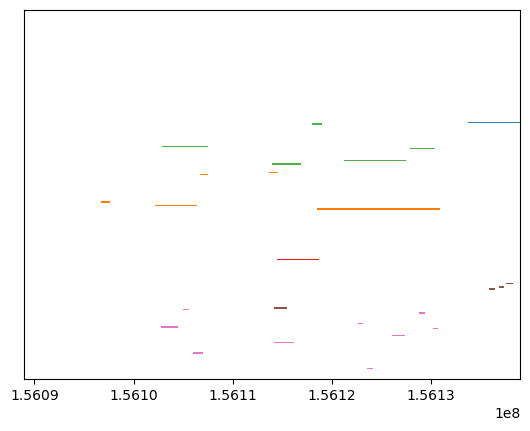

In [151]:
from alphagenome.visualization.plot_transcripts import draw_interval

fig, ax = plt.subplots()
intervals = [
    genome.Interval(row.chrom, int(row.start), int(row.end), name=row["name"])
    for _, row in bed_df.iterrows()
]
for i, (interval, color) in enumerate(zip(intervals, bed_df["color"])):
    draw_interval(
        ax=ax,
        interval=interval,
        y=i,                    # stack vertically; use 0 for all on one row
        height=0.8,
        color=color,            # passed through to Rectangle
        # label=bed_df["category"].iloc[i],  # optional
    )
ax.set_xlim(plot_interval.start, plot_interval.end)
ax.set_ylim(-1, len(intervals))
ax.set_yticks([])
fig.show()

## Multi-track plot with BED overlay

Plot RNA-seq, CAGE, ChIP, ATAC, and DNase tracks for a zoomed window, overlay predicted regions, and optionally save the figure.


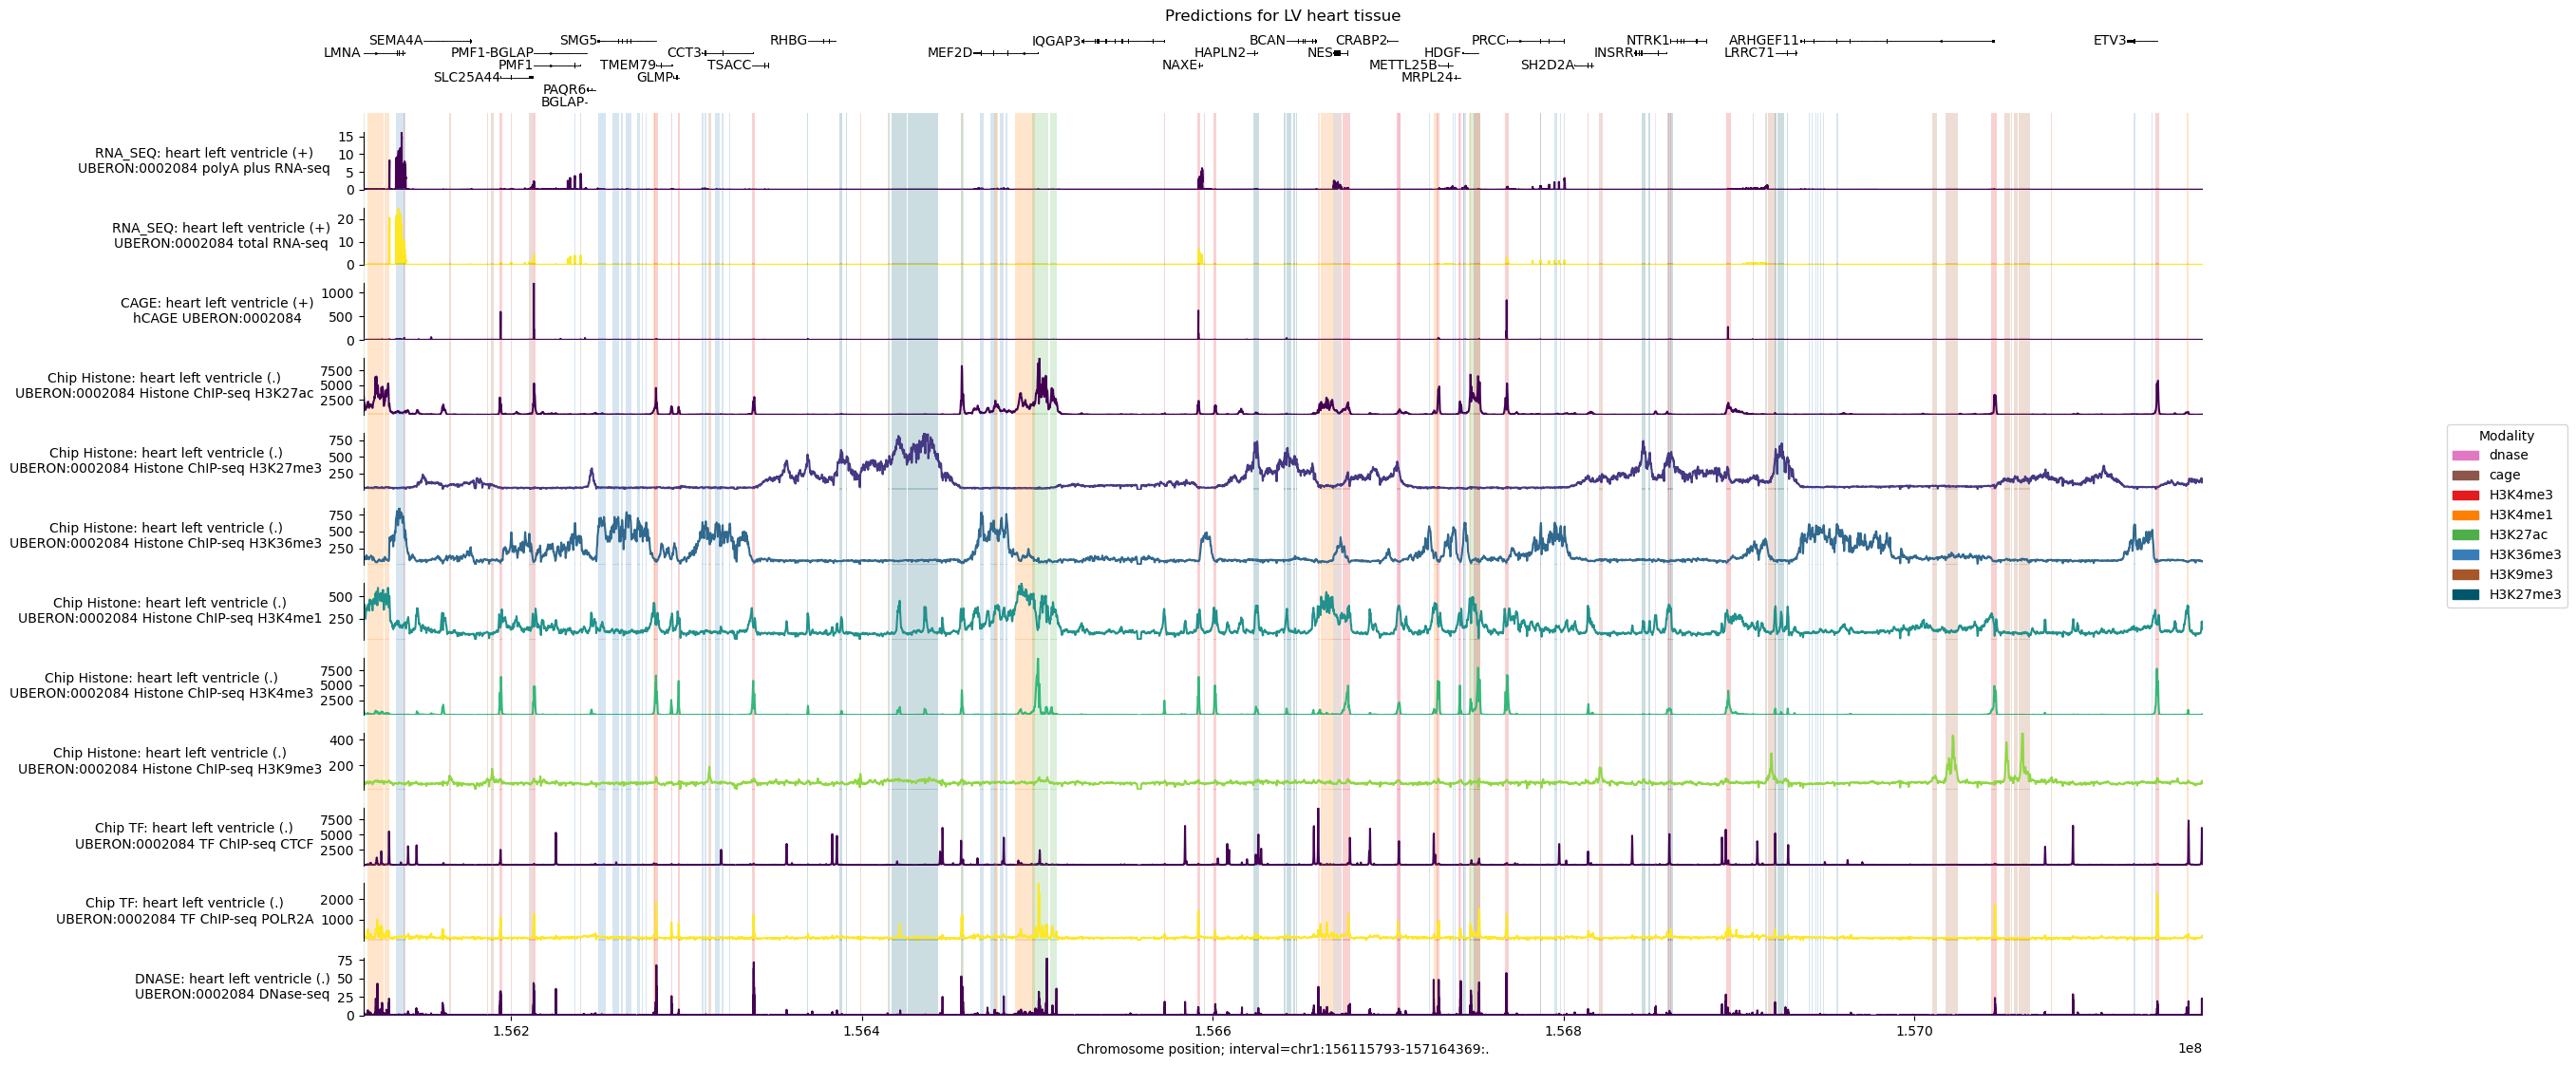

In [81]:

plot_interval = POST_INTERVAL
# plot_interval = genome.Interval('chr1', POST_INTERVAL.start, POST_INTERVAL.start + 50000)
# plot_interval = genome.Interval('chr1', PRE_INTERVAL.end - 50000, PRE_INTERVAL.end)
# plot_interval = genome.Interval('chr1', LMNA_START - 10000, LMNA_END + 10000)
save = True
add_annos = True

# Build plot.
plot = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(longest_transcripts),
        plot_components.Tracks(
            tdata=output.rna_seq.filter_to_positive_strand(),
            ylabel_template='RNA_SEQ: {biosample_name} ({strand})\n{name}',
        ),
        plot_components.Tracks(
            tdata=output.cage.filter_to_positive_strand(),
            ylabel_template='CAGE: {biosample_name} ({strand})\n{name}',
        ),
        # Chip histone.
        plot_components.Tracks(
            tdata=output.chip_histone,
            ylabel_template='Chip Histone: {biosample_name} ({strand})\n{name}',
        ),
        # Chip tf.
        plot_components.Tracks(
            tdata=output.chip_tf,
            ylabel_template='Chip TF: {biosample_name} ({strand})\n{name}',
        ),
        #  # ATAC
        # plot_components.Tracks(
        #     tdata=output.atac,
        #     ylabel_template='ATAC: {biosample_name} ({strand})\n{name}',
        # ),
        # dnase
        plot_components.Tracks(
            tdata=output.dnase,
            ylabel_template='DNASE: {biosample_name} ({strand})\n{name}',
        ),
        #  # splice sites
        # plot_components.Tracks(
        #     tdata=output.splice_sites,
        #     ylabel_template='Splice Sites: ({strand})\n{name}',
        # ),
       
    ],
    # add annotations from a bed file (imported and parsed above)
    annotations=[
        plot_components.IntervalAnnotation(
            bed_intervals, #ccre_intervals,
            colors=colors, #ccre_colors
            alpha=0.2,
            # use_default_labels=False,   # True if you want cCRE IDs as labels
            # labels=bed_df["name"].tolist(),
        ),
    ],
     
    interval=plot_interval,
    fig_width=25,
    title='Predictions for LV heart tissue',
)

# legend_handles = [
#     mpatches.Patch(color=color, label=key) 
#     for key, color in CCRE_COLORS.items()
# ]
# plot.legend(handles=legend_handles, loc="center left", title="Categories",
#           bbox_to_anchor=(1, 0, 0.5, 1))


label_order = list(MODALITY_COLORS) + HISTONE_MARKS
used = [c for c in label_order if c in set(bed_df["category"])]
handles = [
    mpatches.Patch(color=color_from_category(c), label=c)
    for c in used
]
plot.legend(handles=handles, title="Modality", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

if save:
    plot.savefig(f'figs/lmna_predictions_LV_1MB_{lmna_context}_ccres_collapsed.png', dpi=300, bbox_inches="tight")


## Alternate / zoomed annotation plots

Reload a BED for a tight window around the LMNA TSS, then plot transcripts with interval annotations (with or without ChIP-histone tracks).


In [ ]:
plot_interval = genome.Interval('chr1', LMNA_START - 1000, LMNA_START)
# plot_interval = interval

def load_bed_intervals(bed_path, plot_interval=None):
    df = pd.read_csv(bed_path, sep='\t')
    intervals = [
        genome.Interval(
            chromosome=row.chrom,
            start=int(row.start),
            end=int(row.end),
            name=row.name,
            info={'score': row.score},
        )
        for _, row in df.iterrows()
    ]
    if plot_interval is not None:
        intervals = [iv for iv in intervals if plot_interval.contains(iv)]
    return intervals, ccres


bed_intervals, bed_df = load_bed_intervals(BASE_PATH + 'ag/variant-effects/outputs/predicted_reg_regions_pre.bed', plot_interval)
bed_intervals

1
chr1:156114710-156140081:+


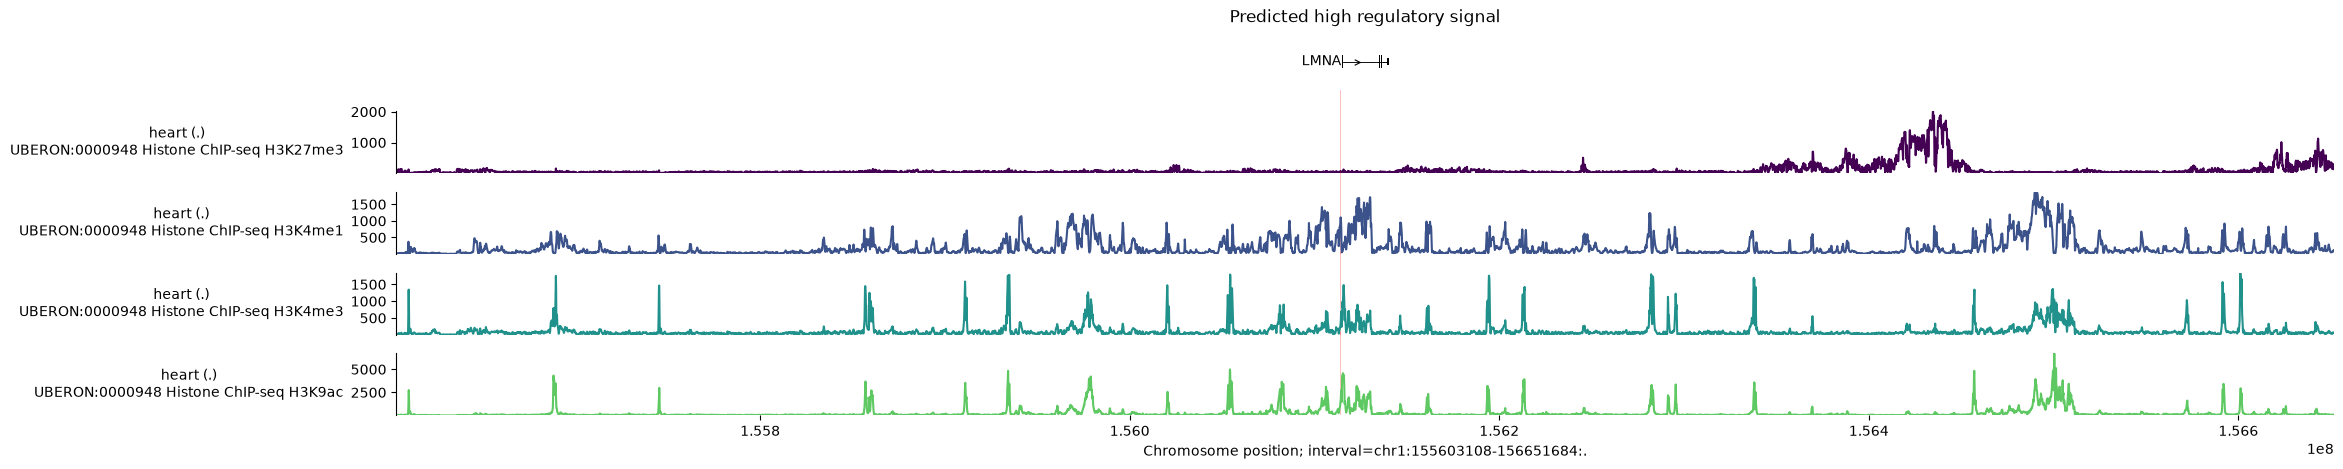

In [306]:
from alphagenome.visualization import plot_components

longest_transcripts_clipped = [
    t for t in longest_transcripts
    if t.transcript_interval.overlaps(plot_interval)
]

print(len(longest_transcripts_clipped))
for t in longest_transcripts_clipped:
    print(t.transcript_interval)



plot = plot_components.plot(
    [plot_components.TranscriptAnnotation(longest_transcripts_clipped),
    # plot_components.Tracks(output.dnase, ylabel_template="{biosample_name}"),
     plot_components.Tracks(output.chip_histone, ylabel_template="{biosample_name} ({strand})\n{name}")
    ],
    
    annotations=[
        # plot_components.IntervalAnnotation(
        #     result["intervals"],
        #     alpha=0.3,
        #     colors=["#00AA00"] * len(result["intervals"]),
        # ),
        
        plot_components.IntervalAnnotation(
            bed_intervals,
            colors='red',
            alpha=0.25,
            use_default_labels=False,   # True if you want cCRE IDs as labels
        ),
    
    ],
    interval=interval,
    title="Predicted high regulatory signal",
    fig_width=25,

)

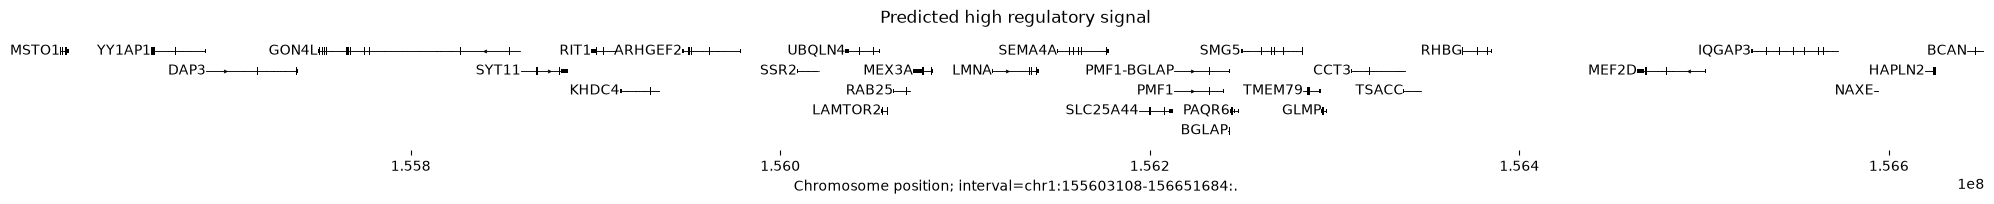

In [304]:
plot = plot_components.plot(
    [plot_components.TranscriptAnnotation(longest_transcripts)],
    
    annotations=[
        plot_components.IntervalAnnotation(
            bed_intervals,
            # colors=ccre_colors,
            alpha=0.25,
            use_default_labels=False,   # True if you want cCRE IDs as labels
        ),
    
    ],
    interval=interval,
    title="Predicted high regulatory signal",
    fig_width=25,

)

## Check plot interval vs transcript spans

Print `plot_interval` and each longest transcript interval for alignment checks.


In [247]:
print(plot_interval)
print('\n')
for i in longest_transcripts:
    print(i.transcript_interval)

chr1:156104711-156114711:.


chr1:155610217-155614951:+
chr1:155169407-155173304:-
chr1:156009047-156020951:-
chr1:155234451-155244670:-
chr1:155173848-155184970:+
chr1:155185825-155192915:-
chr1:155289292-155301438:-
chr1:155255980-155262430:-
chr1:155308915-155320665:+
chr1:156061159-156070504:+
chr1:155946853-155978547:-
chr1:155247204-155255483:-
chr1:156114710-156140081:+
chr1:156054781-156058506:+
chr1:156035298-156053798:-
chr1:155913044-155934413:-
chr1:155897807-155911349:-
chr1:155859566-155885199:+
chr1:155659445-155689000:-
chr1:155689090-155739010:+
chr1:155335267-155562693:-
chr1:155323936-155331114:+
chr1:155277462-155289848:+
chr1:155262867-155273504:-
chr1:155208694-155213823:+
chr1:155139890-155140531:-
chr1:155135811-155138857:+
chr1:155127875-155134899:+
chr1:156072012-156082465:-
chr1:155195589-155207981:-
chr1:155749661-155859400:-


# Scratch / exploratory

Ad-hoc peeks and experiments kept out of the main analysis path. Safe to ignore for a top-to-bottom run.


## Commented contact-map plot


In [80]:
# plot = plot_components.plot(
#     [
#         plot_components.TranscriptAnnotation(longest_transcripts),
#         plot_components.ContactMaps(
#             tdata=output.contact_maps,
#             ylabel_template='{biosample_name}\n{name}',
#             cmap='autumn_r',
#             vmax=1.0,
#         ),
#     ],
#     interval=interval,
#     title='Predicted contact maps',
# )
# plt.show()

## Total RNA-seq track values


In [92]:
total_rna_seq = output.rna_seq.filter_tracks((output.rna_seq.metadata['Assay title'] == 'total RNA-seq').values)
total_rna_seq.values

array([[1.1742115e-05, 1.6570091e-05],
       [1.3828278e-05, 2.0027161e-05],
       [1.6093254e-05, 2.2292137e-05],
       ...,
       [3.7231445e-03, 8.2969666e-05],
       [4.6997070e-03, 1.3828278e-04],
       [5.3100586e-03, 1.8882751e-04]], shape=(1048576, 2), dtype=float32)

## Save total RNA-seq to NPZ


In [93]:
np.savez_compressed("total-rna-seq.npz", total_rna_seq.values)

## Peek ATAC output


In [116]:
output.atac

TrackData(values=array([], shape=(1048576, 0), dtype=float32), metadata=Empty DataFrame
Columns: [name, strand, Assay title, ontology_curie, biosample_name, biosample_type, biosample_life_stage, data_source, endedness, genetically_modified, nonzero_mean]
Index: [], resolution=1, interval=Interval(chromosome='chr1', start=155603108, end=156651684, strand='.', name=''), uns=None)

## Peek ChIP-histone output


In [110]:
output.chip_histone

TrackData(values=array([[ 51.5  ,  29.875,  26.5  ,  56.   ],
       [ 61.75 ,  23.   ,  23.875,  56.5  ],
       [ 92.5  ,  16.25 ,  23.875,  54.25 ],
       ...,
       [244.   , 110.   ,  65.   , 101.   ],
       [156.   ,  89.5  ,  52.5  , 100.5  ],
       [137.   ,  99.5  ,  53.75 , 109.5  ]],
      shape=(8192, 4), dtype=float32), metadata=                                         name strand       Assay title  \
794  UBERON:0000948 Histone ChIP-seq H3K27me3      .  Histone ChIP-seq   
795   UBERON:0000948 Histone ChIP-seq H3K4me1      .  Histone ChIP-seq   
796   UBERON:0000948 Histone ChIP-seq H3K4me3      .  Histone ChIP-seq   
797    UBERON:0000948 Histone ChIP-seq H3K9ac      .  Histone ChIP-seq   

     ontology_curie biosample_name biosample_type biosample_life_stage  \
794  UBERON:0000948          heart         tissue            embryonic   
795  UBERON:0000948          heart         tissue            embryonic   
796  UBERON:0000948          heart         tissue          

## pyGenomeViz example (unrelated demo)


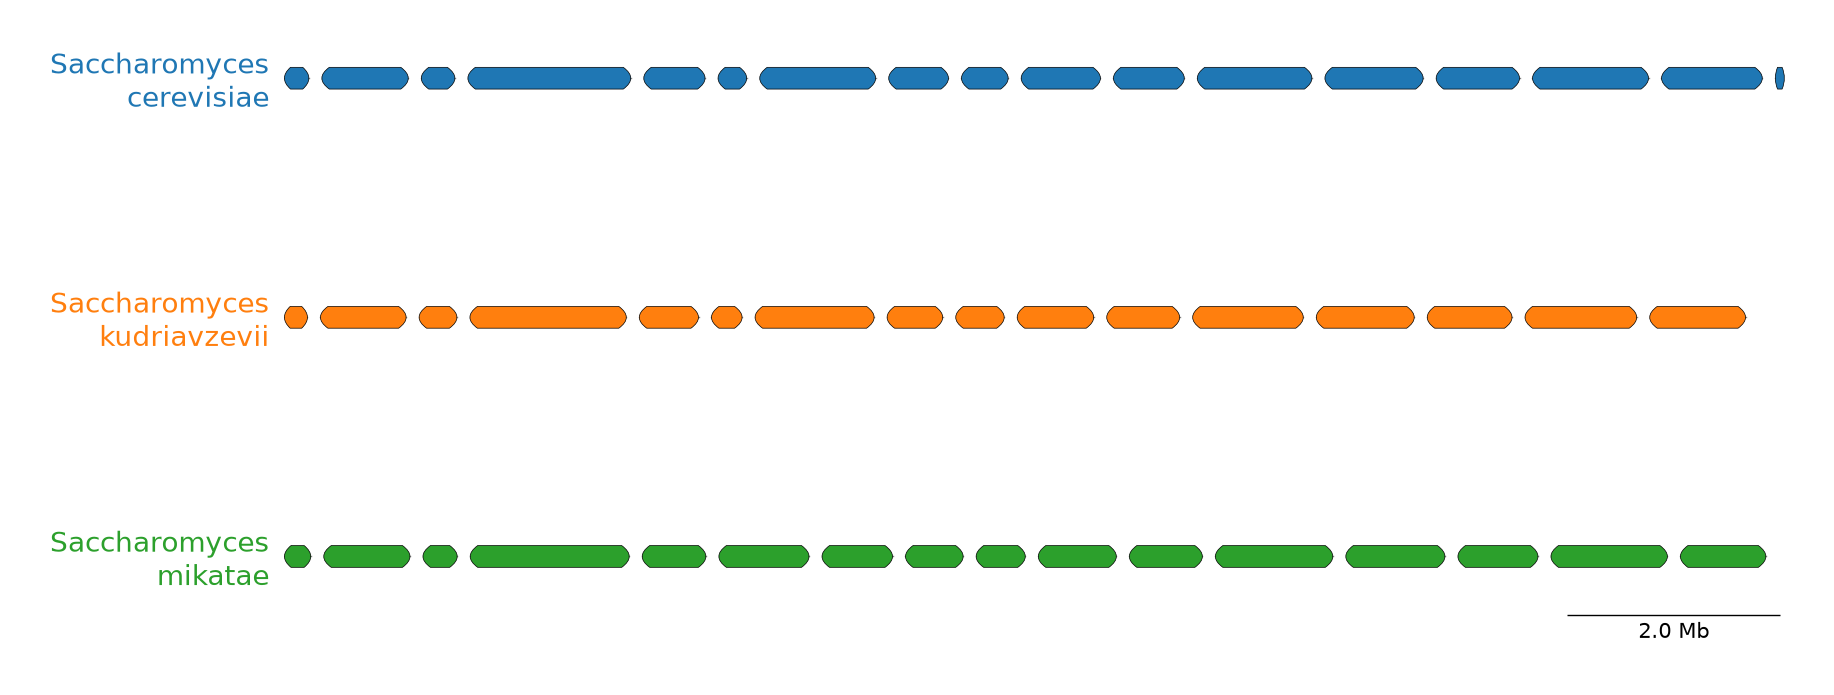

In [309]:
from pygenomeviz import GenomeViz
# from pygenomeviz.align import MUMmer
from pygenomeviz.parser import Genbank
from pygenomeviz.utils import load_example_genbank_dataset, ColorCycler
from Bio import SeqIO
ColorCycler.set_cmap("tab10")

gbk_files = load_example_genbank_dataset("saccharomyces")
gbk_list = list(map(Genbank, gbk_files))

gv = GenomeViz(feature_track_ratio=0.1)
gv.set_scale_bar(ymargin=2.0)

# Plot chromosomes
for gbk in gbk_list:
    color = ColorCycler()
    track = gv.add_feature_track(gbk.name, gbk.get_seqid2size(), space=0.01, label_kws=dict(color=color))
    track.set_label(track.name.replace("_", "\n"))
    for segment in track.segments:
        segment.add_feature(segment.start, segment.end, plotstyle="bigrbox", fc=color, lw=0.5)

# # # Run MUMmer alignment
# align_coords = MUMmer(gbk_list).run()

# # # Plot MUMmer alignment links
# if len(align_coords) > 0:
#     for ac in align_coords:
#         gv.add_link(ac.query_link, ac.ref_link, color="grey", inverted_color="red", curve=True, filter_length=1000)

fig = gv.plotfig()

## Read hg38 FASTA with Biopython


In [310]:
human = SeqIO.read(HG38_FASTA_PATH, "fasta")
human

ValueError: More than one record found in handle